
# Exercícios — Séries Temporais com `yfinance`

Este notebook apresenta **quatro exercícios práticos** sobre séries temporais financeiras.
Use o `yfinance` para coletar e analisar dados, explorando tendência, sazonalidade e ruído.




## 1) Coleta e visualização de dados

Baixe os dados **diários** de fechamento da ação `PETR4.SA` dos **últimos 5 anos** usando `yfinance`.

Tarefas:
1. Mostre as 5 primeiras linhas do DataFrame.
2. Plote o gráfico de **fechamento diário**.
3. Comente se há **tendência** observável.

Dica: use `yf.download('PETR4.SA', start='2019-01-01')`.


In [1]:
# Instalação das principais bibliotecas
!pip install yfinance --upgrade --quiet
!pip install statsmodels --quiet


# Importação das bibliotecas

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose



import warnings
warnings.filterwarnings('ignore')

print ("Instalação e importação da biblioteca realizado com sucesso!!!!")

Instalação e importação da biblioteca realizado com sucesso!!!!


In [5]:
# @title Escolha as empresas que deseja analisar
# @markdown Escolha as empresas que deseja analisar abaixo:
PETR4_SA = True  # @param {type:"boolean"}

data_inicial = '2019-01-01'  # @param {type:"date"}
data_final = '2025-10-27'    # @param {type:"date"}

import yfinance as yf

# Monta a lista de tickers com base nas seleções
tickers = []

if PETR4_SA:
    tickers.append("PETR4.SA")  # <- aqui o ticker certo, com ponto!

print("\n----------------------\n")
print("Empresas selecionadas:\n", tickers)

# Baixa os dados
dados = yf.download(tickers, start=data_inicial, end=data_final)['Close']

dados.head()


[*********************100%***********************]  1 of 1 completed


----------------------

Empresas selecionadas:
 ['PETR4.SA']


Ticker,PETR4.SA
Date,
2019-01-02,6.898341
2019-01-03,7.067499
2019-01-04,7.087572
2019-01-07,7.199389
2019-01-08,7.156384


In [6]:
dados = yf.download('PETR4.SA', start = '2019-01-01')
print("Primeiras linhas dos dados da PETR4.SA")
display(dados.head())

[*********************100%***********************]  1 of 1 completed

Primeiras linhas dos dados da PETR4.SA


Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
Date,,,,,
2019-01-02,6.898340,6.938480,6.387989,6.465401,104534800
2019-01-03,7.067500,7.116242,6.823793,6.869667,95206400
2019-01-04,7.087571,7.150648,7.015892,7.124844,72119800
2019-01-07,7.199388,7.431626,7.081835,7.124842,121711900
2019-01-08,7.156381,7.288269,7.101905,7.282535,68761800


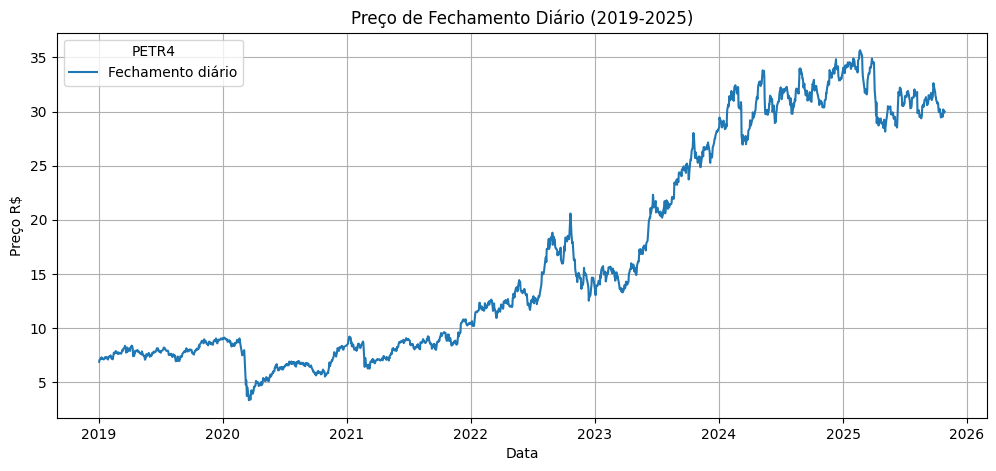

In [8]:
#Para plotar o gráfico do fechamento diário

plt.figure(figsize=(12,5))
plt.plot(dados['Close'], label='Fechamento diário')
plt.title('Preço de Fechamento Diário (2019-2025)')
plt.xlabel('Data')
plt.ylabel('Preço R$')
plt.legend(title = 'PETR4')
plt.grid(True)
plt.show()

In [18]:
print("Colunas do DataFrame:")
print(dados.columns)
print("\nAs 5 primeiras linhas:")
print(dados.head())


Colunas do DataFrame:
Index(['Close_PETR4.SA', 'High_PETR4.SA', 'Low_PETR4.SA', 'Open_PETR4.SA',
       'Volume_PETR4.SA', 'mm7'],
      dtype='object')

As 5 primeiras linhas:
            Close_PETR4.SA  High_PETR4.SA  Low_PETR4.SA  Open_PETR4.SA  \
Date                                                                     
2019-01-02        6.898340       6.938480      6.387989       6.465401   
2019-01-03        7.067501       7.116242      6.823794       6.869668   
2019-01-04        7.087571       7.150649      7.015893       7.124844   
2019-01-07        7.199389       7.431627      7.081836       7.124843   
2019-01-08        7.156382       7.288270      7.101906       7.282536   

            Volume_PETR4.SA  mm7  
Date                              
2019-01-02        104534800  NaN  
2019-01-03         95206400  NaN  
2019-01-04         72119800  NaN  
2019-01-07        121711900  NaN  
2019-01-08         68761800  NaN  


[*********************100%***********************]  1 of 1 completed


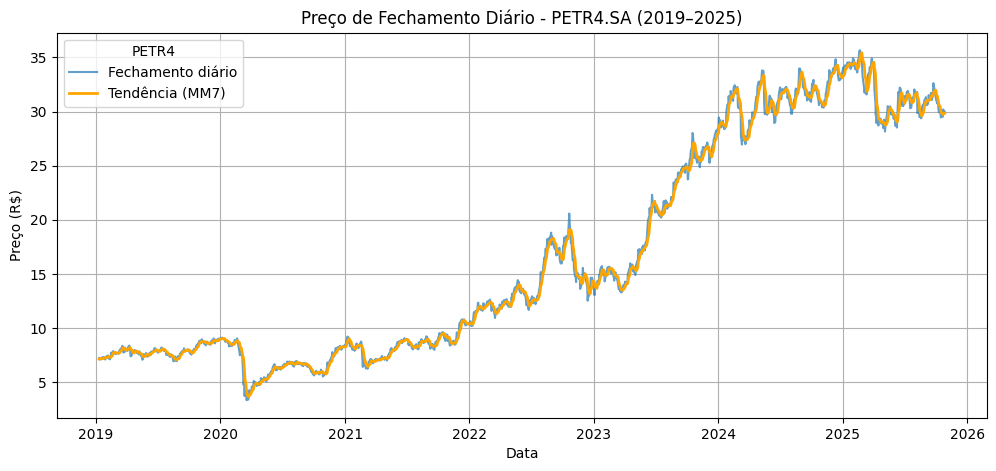

In [15]:
import yfinance as yf
import matplotlib.pyplot as plt

# Baixar dados
dados = yf.download('PETR4.SA', start='2019-01-01')

# Achatar as colunas MultiIndex
dados.columns = ['_'.join(col).strip() if col[1] != '' else col[0] for col in dados.columns]

# Agora os nomes ficam: Close_PETR4.SA, High_PETR4.SA, etc.

# Criar média móvel de 7 dias
dados['mm7'] = dados['Close_PETR4.SA'].rolling(window=7).mean()

# Remover NaN iniciais
dados_plot = dados.dropna(subset=['mm7'])

# Plotar
plt.figure(figsize=(12,5))
plt.plot(dados_plot['Close_PETR4.SA'], label='Fechamento diário', alpha=0.7)
plt.plot(dados_plot['mm7'], label='Tendência (MM7)', color='orange', linewidth=2)

plt.title('Preço de Fechamento Diário - PETR4.SA (2019–2025)')
plt.xlabel('Data')
plt.ylabel('Preço (R$)')
plt.legend(title='PETR4')
plt.grid(True)
plt.show()



## 2) Tendência via médias móveis

Utilize o mesmo DataFrame e calcule:
1. As **médias móveis** de 7, 30 e 90 dias.
2. Plote o gráfico com as três médias móveis e o fechamento.
3. Explique o que cada média móvel representa (curto, médio e longo prazo).


### MM7 (curto prazo)
  1. Média dos últimos 7 dias.
  2. Apresenta a tendência recente,podendo ver movimentos pontuais.

### MM30 (médio prazo)
  1. Média dos últimos 30 dias.
  2. Apresenta uma tendência intermediária, ajuda a filtrar oscilações diárias e ver o movimento geral do mês.

### MM90 (longo prazo)
  1. Média dos últimos 90 dias.
  2. Apresenta tendência de longo prazo, ideal para identificar direção geral do mercado e estabilidade do preço.

[*********************100%***********************]  1 of 1 completed


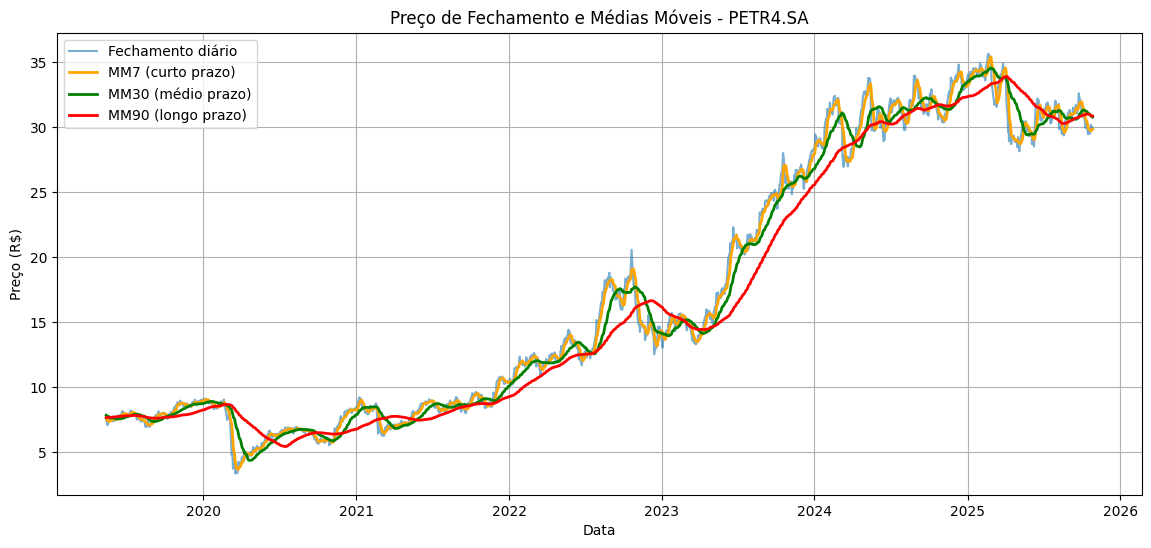

In [19]:
import yfinance as yf
import matplotlib.pyplot as plt

# Baixar dados
dados = yf.download('PETR4.SA', start='2019-01-01')

# Achatar MultiIndex das colunas
dados.columns = ['_'.join(col).strip() if col[1] != '' else col[0] for col in dados.columns]

# Calcular médias móveis
dados['MM7'] = dados['Close_PETR4.SA'].rolling(window=7).mean()    # curto prazo
dados['MM30'] = dados['Close_PETR4.SA'].rolling(window=30).mean()  # médio prazo
dados['MM90'] = dados['Close_PETR4.SA'].rolling(window=90).mean()  # longo prazo

# Remover linhas iniciais com NaN (opcional)
dados_plot = dados.dropna(subset=['MM7', 'MM30', 'MM90'])

# Plotar gráfico
plt.figure(figsize=(14,6))
plt.plot(dados_plot['Close_PETR4.SA'], label='Fechamento diário', alpha=0.6)
plt.plot(dados_plot['MM7'], label='MM7 (curto prazo)', color='orange', linewidth=2)
plt.plot(dados_plot['MM30'], label='MM30 (médio prazo)', color='green', linewidth=2)
plt.plot(dados_plot['MM90'], label='MM90 (longo prazo)', color='red', linewidth=2)

plt.title('Preço de Fechamento e Médias Móveis - PETR4.SA')
plt.xlabel('Data')
plt.ylabel('Preço (R$)')
plt.legend()
plt.grid(True)
plt.show()



## 3) Decomposição da série (aditiva)

Converta a série diária em **mensal** usando `resample('M').mean()` e aplique a **decomposição aditiva**.

Tarefas:
1. Gere a série mensal de fechamento.
2. Aplique `seasonal_decompose` com `model='additive'` e `period=12`.
3. Plote os componentes (observado, tendência, sazonalidade e resíduos).
4. Descreva o que observou em cada componente.


[*********************100%***********************]  1 of 1 completed


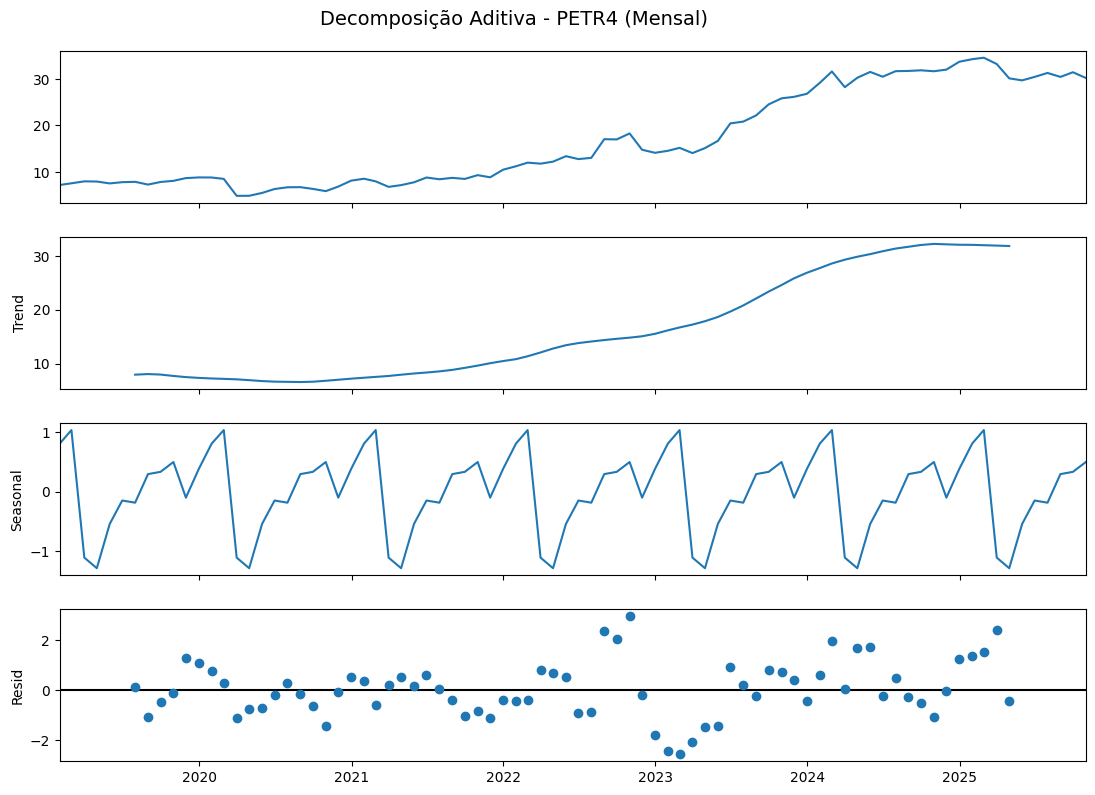

Ticker      PETR4.SA
Date                
2019-01-31  7.198707
2019-02-28  7.557065
2019-03-31  7.976535
2019-04-30  7.937983
2019-05-31  7.532486
2019-06-30  7.797590
2019-07-31  7.873332
2019-08-31  7.285637
2019-09-30  7.839524
2019-10-31  8.090084
2019-11-30  8.672992
2019-12-31  8.823176
2020-01-31  8.806336
2020-02-29  8.504652
2020-03-31  4.857893


In [20]:
import pandas as pd
import yfinance as yf
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# 1️⃣ Baixar dados da PETR4
dados = yf.download('PETR4.SA', start='2019-01-01')

# 2️⃣ Converter para série mensal (média do mês)
serie_mensal = dados['Close'].resample('M').mean()

# 3️⃣ Decomposição aditiva
decomposicao = seasonal_decompose(serie_mensal, model='additive', period=12)

# 4️⃣ Plotar os componentes
fig = decomposicao.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Decomposição Aditiva - PETR4 (Mensal)', fontsize=14, y=1.02)
plt.show()

# Mostrar um pedaço da série mensal para referência
print(serie_mensal.head(15))



## 4) Autocorrelação (ACF) e sazonalidade

Calcule e plote a **função de autocorrelação (ACF)** da série mensal.

Tarefas:
1. Use `plot_acf` sobre a série mensal ou os resíduos da decomposição.
2. Identifique *lags* com correlação significativa.
3. Indique se há sinais de **sazonalidade** (padrões repetitivos).


<Figure size 1000x500 with 0 Axes>

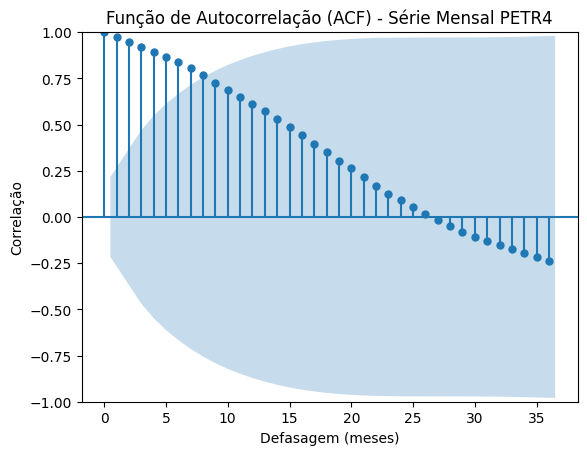

In [21]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Se ainda não tiver a série mensal, cria de novo só pra garantir
serie_mensal = dados['Close'].resample('M').mean()

# 1️⃣ Plotar a ACF da série mensal
plt.figure(figsize=(10,5))
plot_acf(serie_mensal.dropna(), lags=36)
plt.title('Função de Autocorrelação (ACF) - Série Mensal PETR4')
plt.xlabel('Defasagem (meses)')
plt.ylabel('Correlação')
plt.show()
